In [1]:
import os
import joblib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================================
# PHASE 6 — LOAD TRAINED MODELS
# ============================================================

SUPERVISED_DIR = "../models/supervised"
ANOMALY_DIR = "../models/anomaly"

# Load supervised models
logistic_model = joblib.load(
    "../models/logistic_regression.joblib"
)

random_forest_model = joblib.load(
    os.path.join(SUPERVISED_DIR, "random_forest.joblib")
)

xgb_model = joblib.load(
    os.path.join(SUPERVISED_DIR, "xgboost.joblib")
)

lgbm_model = joblib.load(
    os.path.join(SUPERVISED_DIR, "lightgbm.joblib")
)

# Load anomaly detection model
isolation_forest = joblib.load(
    os.path.join(ANOMALY_DIR, "isolation_forest.joblib")
)

print("All trained models loaded successfully!")
print()
print("Logistic Regression :", type(logistic_model))
print("Random Forest       :", type(random_forest_model))
print("XGBoost             :", type(xgb_model))
print("LightGBM            :", type(lgbm_model))
print("Isolation Forest    :", type(isolation_forest))

All trained models loaded successfully!

Logistic Regression : <class 'sklearn.linear_model._logistic.LogisticRegression'>
Random Forest       : <class 'sklearn.ensemble._forest.RandomForestClassifier'>
XGBoost             : <class 'xgboost.sklearn.XGBClassifier'>
LightGBM            : <class 'lightgbm.sklearn.LGBMClassifier'>
Isolation Forest    : <class 'sklearn.ensemble._iforest.IsolationForest'>


In [4]:
import os

print("Searching for CSV files...")
print("=" * 70)

for root, dirs, files in os.walk("../data"):
    for file in files:
        if file.lower().endswith(".csv"):
            print(os.path.join(root, file))

Searching for CSV files...
../data\processed\cleaned_data.csv
../data\raw\CIC-IDS2017\MachineLearningCVE\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
../data\raw\CIC-IDS2017\MachineLearningCVE\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
../data\raw\CIC-IDS2017\MachineLearningCVE\Friday-WorkingHours-Morning.pcap_ISCX.csv
../data\raw\CIC-IDS2017\MachineLearningCVE\Monday-WorkingHours.pcap_ISCX.csv
../data\raw\CIC-IDS2017\MachineLearningCVE\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
../data\raw\CIC-IDS2017\MachineLearningCVE\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
../data\raw\CIC-IDS2017\MachineLearningCVE\Tuesday-WorkingHours.pcap_ISCX.csv
../data\raw\CIC-IDS2017\MachineLearningCVE\Wednesday-workingHours.pcap_ISCX.csv


In [5]:
# ============================================================
# PHASE 6 — LOAD DATASET AND PREPROCESSING OBJECTS
# ============================================================

DATA_PATH = "../data/processed/cleaned_data.csv"
PREPROCESSING_DIR = "../models/preprocessing"

# Load dataset
df = pd.read_csv(DATA_PATH)

# Load preprocessing objects
scaler = joblib.load(
    os.path.join(PREPROCESSING_DIR, "scaler.joblib")
)

label_encoder = joblib.load(
    os.path.join(PREPROCESSING_DIR, "label_encoder.joblib")
)

print("Dataset and preprocessing objects loaded successfully!")
print("Dataset shape:", df.shape)
print("Number of classes:", len(label_encoder.classes_))
print("Number of features:", df.shape[1] - 1)

Dataset and preprocessing objects loaded successfully!
Dataset shape: (2830743, 79)
Number of classes: 15
Number of features: 78


In [6]:
# ============================================================
# PHASE 6 — RECREATE FEATURE MATRIX
# ============================================================

# Separate features and target
X = df.drop(columns=["Label"])
y = df["Label"]

# Encode target labels
y = label_encoder.transform(y)

# Use the same 45 features used during model training
feature_columns = [
    "Destination Port",
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Fwd Packet Length Max",
    "Fwd Packet Length Min",
    "Fwd Packet Length Mean",
    "Fwd Packet Length Std",
    "Bwd Packet Length Max",
    "Bwd Packet Length Min",
    "Bwd Packet Length Mean",
    "Bwd Packet Length Std",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Flow IAT Std",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Total",
    "Fwd IAT Mean",
    "Fwd IAT Std",
    "Fwd IAT Max",
    "Fwd IAT Min",
    "Bwd IAT Total",
    "Bwd IAT Mean",
    "Bwd IAT Std",
    "Bwd IAT Max",
    "Bwd IAT Min",
    "Fwd PSH Flags",
    "Fwd URG Flags",
    "Fwd Header Length",
    "Bwd Header Length",
    "Fwd Packets/s",
    "Bwd Packets/s",
    "Min Packet Length",
    "Max Packet Length",
    "Packet Length Mean",
    "Packet Length Std",
    "Packet Length Variance",
    "FIN Flag Count",
    "SYN Flag Count",
    "RST Flag Count",
    "ACK Flag Count"
]

X = X[feature_columns]

print("Feature matrix recreated successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", X.shape[1])

Feature matrix recreated successfully!
X shape: (2830743, 45)
y shape: (2830743,)
Number of features: 45


In [7]:
# ============================================================
# PHASE 6 — EXACT 45 FEATURES FROM PHASE 4
# ============================================================

FEATURES = [
    "Destination Port",
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Fwd Packet Length Max",
    "Fwd Packet Length Min",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Max",
    "Bwd Packet Length Min",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Flow IAT Std",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Mean",
    "Fwd IAT Std",
    "Fwd IAT Min",
    "Bwd IAT Total",
    "Bwd IAT Mean",
    "Bwd IAT Std",
    "Bwd IAT Max",
    "Bwd IAT Min",
    "Fwd PSH Flags",
    "Fwd URG Flags",
    "Bwd Packets/s",
    "Min Packet Length",
    "Max Packet Length",
    "Packet Length Mean",
    "Packet Length Variance",
    "FIN Flag Count",
    "RST Flag Count",
    "PSH Flag Count",
    "ACK Flag Count",
    "URG Flag Count",
    "ECE Flag Count",
    "Down/Up Ratio",
    "Init_Win_bytes_forward",
    "Init_Win_bytes_backward",
    "min_seg_size_forward",
    "Active Mean",
    "Active Std",
    "Active Max",
    "Active Min",
    "Idle Std"
]

X = df[FEATURES]
y = label_encoder.transform(df["Label"])

print("Exact Phase 4 feature matrix recreated successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", len(FEATURES))

Exact Phase 4 feature matrix recreated successfully!
X shape: (2830743, 45)
y shape: (2830743,)
Number of features: 45


In [8]:
# ============================================================
# PHASE 6 — RECREATE EXACT DATA SPLIT
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Exact train/validation/test split recreated!")
print()
print("Training set   :", X_train.shape, y_train.shape)
print("Validation set :", X_val.shape, y_val.shape)
print("Test set       :", X_test.shape, y_test.shape)

Exact train/validation/test split recreated!

Training set   : (1981520, 45) (1981520,)
Validation set : (424611, 45) (424611,)
Test set       : (424612, 45) (424612,)


In [9]:
# ============================================================
# PHASE 6 — PREPARE SCALED TEST DATA
# ============================================================

X_test_scaled = scaler.transform(X_test)

print("Scaled test data recreated successfully!")
print("X_test_scaled shape:", X_test_scaled.shape)

Scaled test data recreated successfully!
X_test_scaled shape: (424612, 45)


In [10]:
# ============================================================
# PHASE 6 — LOGISTIC REGRESSION EVALUATION
# ============================================================

# Generate predictions
logistic_predictions = logistic_model.predict(X_test_scaled)

# Calculate metrics
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    average="macro",
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    average="macro",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    average="macro",
    zero_division=0
)

print("Logistic Regression — Test Set Results")
print("=" * 60)
print(f"Accuracy        : {logistic_accuracy:.4f}")
print(f"Macro Precision : {logistic_precision:.4f}")
print(f"Macro Recall    : {logistic_recall:.4f}")
print(f"Macro F1        : {logistic_f1:.4f}")

Logistic Regression — Test Set Results
Accuracy        : 0.9742
Macro Precision : 0.7162
Macro Recall    : 0.5967
Macro F1        : 0.6207


In [11]:
# ============================================================
# PHASE 6 — RANDOM FOREST EVALUATION
# ============================================================

# Generate predictions
rf_predictions = random_forest_model.predict(X_test)

# Calculate metrics
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average="macro",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average="macro",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="macro",
    zero_division=0
)

print("Random Forest — Test Set Results")
print("=" * 60)
print(f"Accuracy        : {rf_accuracy:.4f}")
print(f"Macro Precision : {rf_precision:.4f}")
print(f"Macro Recall    : {rf_recall:.4f}")
print(f"Macro F1        : {rf_f1:.4f}")

Random Forest — Test Set Results
Accuracy        : 0.9986
Macro Precision : 0.9057
Macro Recall    : 0.8465
Macro F1        : 0.8654


In [12]:
# ============================================================
# PHASE 6 — XGBOOST EVALUATION
# ============================================================

# Generate predictions
xgb_predictions = xgb_model.predict(X_test)

# Calculate metrics
xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

xgb_precision = precision_score(
    y_test,
    xgb_predictions,
    average="macro",
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    xgb_predictions,
    average="macro",
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    xgb_predictions,
    average="macro",
    zero_division=0
)

print("XGBoost — Test Set Results")
print("=" * 60)
print(f"Accuracy        : {xgb_accuracy:.4f}")
print(f"Macro Precision : {xgb_precision:.4f}")
print(f"Macro Recall    : {xgb_recall:.4f}")
print(f"Macro F1        : {xgb_f1:.4f}")

XGBoost — Test Set Results
Accuracy        : 0.9989
Macro Precision : 0.9414
Macro Recall    : 0.8788
Macro F1        : 0.8951


In [13]:
# ============================================================
# PHASE 6 — LIGHTGBM EVALUATION
# ============================================================

# Generate predictions
lgbm_predictions = lgbm_model.predict(X_test)

# Calculate metrics
lgbm_accuracy = accuracy_score(
    y_test,
    lgbm_predictions
)

lgbm_precision = precision_score(
    y_test,
    lgbm_predictions,
    average="macro",
    zero_division=0
)

lgbm_recall = recall_score(
    y_test,
    lgbm_predictions,
    average="macro",
    zero_division=0
)

lgbm_f1 = f1_score(
    y_test,
    lgbm_predictions,
    average="macro",
    zero_division=0
)

print("LightGBM — Test Set Results")
print("=" * 60)
print(f"Accuracy        : {lgbm_accuracy:.4f}")
print(f"Macro Precision : {lgbm_precision:.4f}")
print(f"Macro Recall    : {lgbm_recall:.4f}")
print(f"Macro F1        : {lgbm_f1:.4f}")

LightGBM — Test Set Results
Accuracy        : 0.8833
Macro Precision : 0.2466
Macro Recall    : 0.1744
Macro F1        : 0.1964


In [14]:
# ============================================================
# PHASE 6 — ISOLATION FOREST EVALUATION
# ============================================================

# Generate Isolation Forest predictions
isolation_predictions = isolation_forest.predict(X_test_scaled)

# Isolation Forest:
# -1 = anomaly
#  1 = normal
# Convert to:
#  1 = attack
#  0 = normal

isolation_predictions = (
    isolation_predictions == -1
).astype(int)

# Convert original 15-class labels into binary labels
# BENIGN = Normal (0)
# Everything else = Attack (1)

benign_label = label_encoder.transform(["BENIGN"])[0]

y_test_binary = (
    y_test != benign_label
).astype(int)

# Calculate metrics
isolation_accuracy = accuracy_score(
    y_test_binary,
    isolation_predictions
)

isolation_precision = precision_score(
    y_test_binary,
    isolation_predictions,
    zero_division=0
)

isolation_recall = recall_score(
    y_test_binary,
    isolation_predictions,
    zero_division=0
)

isolation_f1 = f1_score(
    y_test_binary,
    isolation_predictions,
    zero_division=0
)

print("Isolation Forest — Test Set Results")
print("=" * 60)
print(f"Accuracy  : {isolation_accuracy:.4f}")
print(f"Precision : {isolation_precision:.4f}")
print(f"Recall    : {isolation_recall:.4f}")
print(f"F1 Score  : {isolation_f1:.4f}")

Isolation Forest — Test Set Results
Accuracy  : 0.7884
Precision : 0.3894
Recall    : 0.1306
F1 Score  : 0.1956


In [15]:
# ============================================================
# PHASE 6 — SUPERVISED MODEL COMPARISON
# ============================================================

supervised_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        xgb_accuracy,
        lgbm_accuracy
    ],
    "Macro Precision": [
        logistic_precision,
        rf_precision,
        xgb_precision,
        lgbm_precision
    ],
    "Macro Recall": [
        logistic_recall,
        rf_recall,
        xgb_recall,
        lgbm_recall
    ],
    "Macro F1": [
        logistic_f1,
        rf_f1,
        xgb_f1,
        lgbm_f1
    ]
})

print("Final Supervised Model Comparison")
print("=" * 80)
print(supervised_results.round(4).to_string(index=False))

Final Supervised Model Comparison
              Model  Accuracy  Macro Precision  Macro Recall  Macro F1
Logistic Regression    0.9742           0.7162        0.5967    0.6207
      Random Forest    0.9986           0.9057        0.8465    0.8654
            XGBoost    0.9989           0.9414        0.8788    0.8951
           LightGBM    0.8833           0.2466        0.1744    0.1964


In [16]:
# ============================================================
# PHASE 6 — ISOLATION FOREST SUMMARY
# ============================================================

isolation_results = pd.DataFrame({
    "Model": ["Isolation Forest"],
    "Accuracy": [isolation_accuracy],
    "Precision": [isolation_precision],
    "Recall": [isolation_recall],
    "F1 Score": [isolation_f1]
})

print("Isolation Forest Evaluation")
print("=" * 60)
print(isolation_results.round(4).to_string(index=False))

Isolation Forest Evaluation
           Model  Accuracy  Precision  Recall  F1 Score
Isolation Forest    0.7884     0.3894  0.1306    0.1956


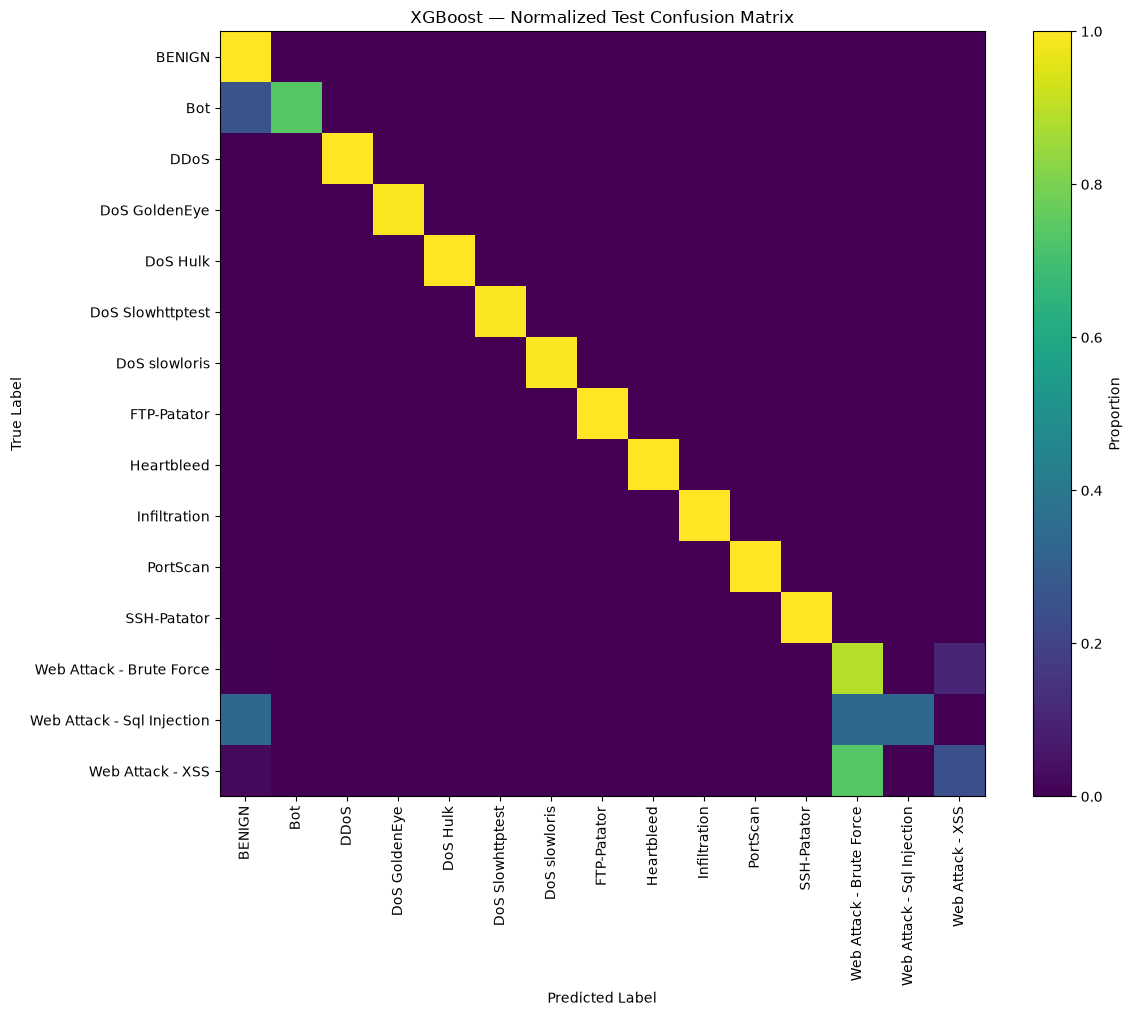

In [17]:
# ============================================================
# PHASE 6 — XGBOOST NORMALIZED CONFUSION MATRIX
# ============================================================

xgb_cm_normalized = confusion_matrix(
    y_test,
    xgb_predictions,
    normalize="true"
)

plt.figure(figsize=(12, 10))

plt.imshow(
    xgb_cm_normalized,
    interpolation="nearest"
)

plt.title("XGBoost — Normalized Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar(label="Proportion")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.tight_layout()
plt.show()

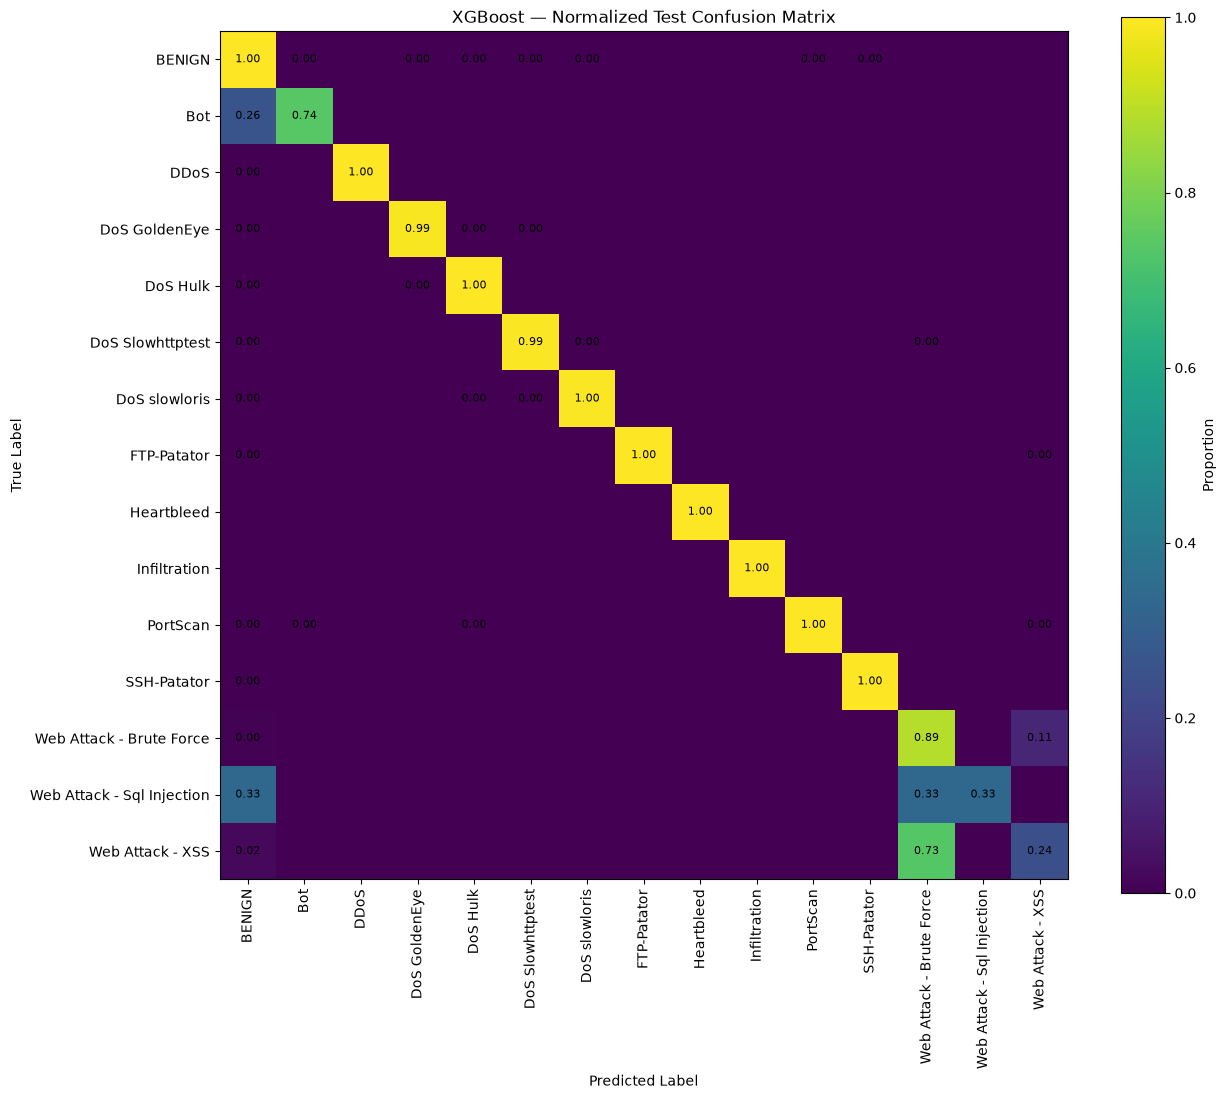

In [18]:
# ============================================================
# PHASE 6 — ANNOTATED XGBOOST CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(13, 11))

plt.imshow(
    xgb_cm_normalized,
    interpolation="nearest"
)

plt.title("XGBoost — Normalized Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar(label="Proportion")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

# Add numerical values
for i in range(xgb_cm_normalized.shape[0]):
    for j in range(xgb_cm_normalized.shape[1]):
        value = xgb_cm_normalized[i, j]

        if value > 0:
            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

plt.tight_layout()
plt.show()

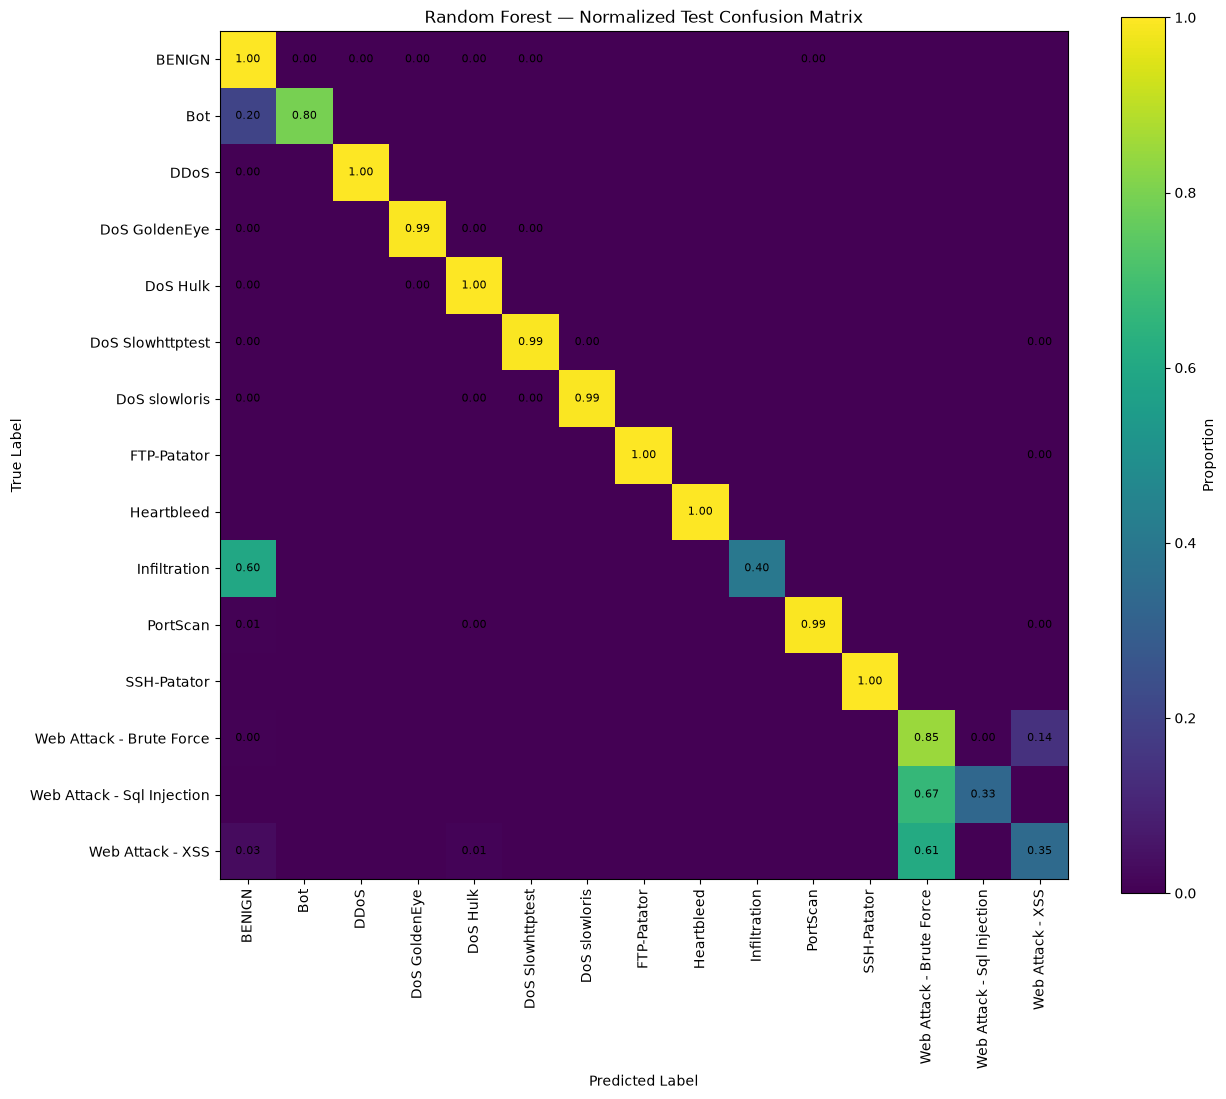

In [19]:
# ============================================================
# PHASE 6 — RANDOM FOREST NORMALIZED CONFUSION MATRIX
# ============================================================

rf_cm_normalized = confusion_matrix(
    y_test,
    rf_predictions,
    normalize="true"
)

plt.figure(figsize=(13, 11))

plt.imshow(
    rf_cm_normalized,
    interpolation="nearest"
)

plt.title("Random Forest — Normalized Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar(label="Proportion")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

# Add numerical values
for i in range(rf_cm_normalized.shape[0]):
    for j in range(rf_cm_normalized.shape[1]):
        value = rf_cm_normalized[i, j]

        if value > 0:
            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

plt.tight_layout()
plt.show()

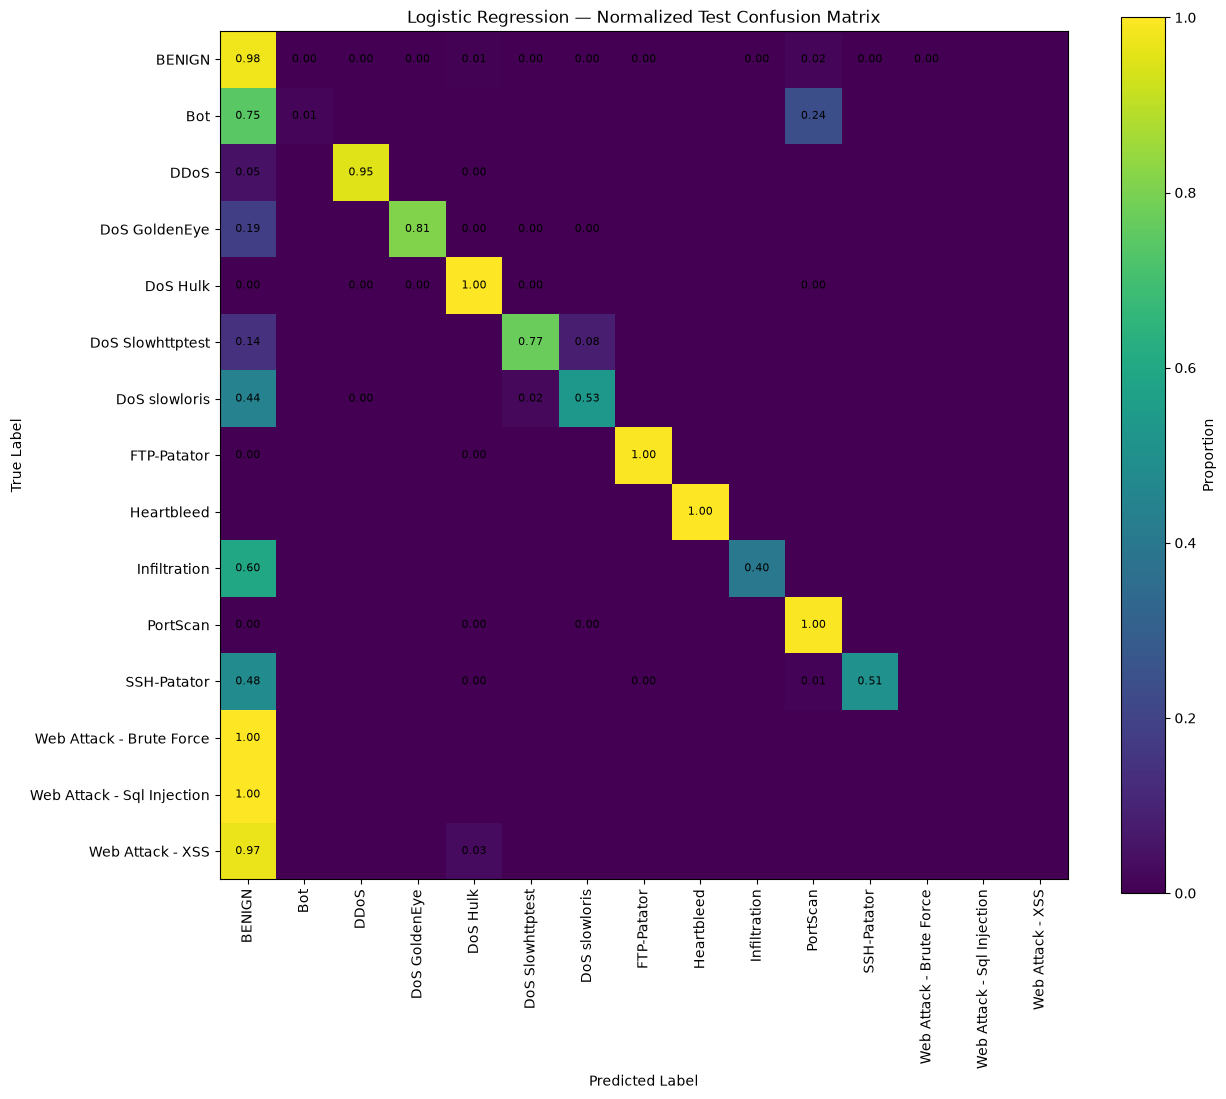

In [20]:
# ============================================================
# PHASE 6 — LOGISTIC REGRESSION NORMALIZED CONFUSION MATRIX
# ============================================================

logistic_cm_normalized = confusion_matrix(
    y_test,
    logistic_predictions,
    normalize="true"
)

plt.figure(figsize=(13, 11))

plt.imshow(
    logistic_cm_normalized,
    interpolation="nearest"
)

plt.title("Logistic Regression — Normalized Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar(label="Proportion")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

# Add numerical values
for i in range(logistic_cm_normalized.shape[0]):
    for j in range(logistic_cm_normalized.shape[1]):
        value = logistic_cm_normalized[i, j]

        if value > 0:
            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

plt.tight_layout()
plt.show()

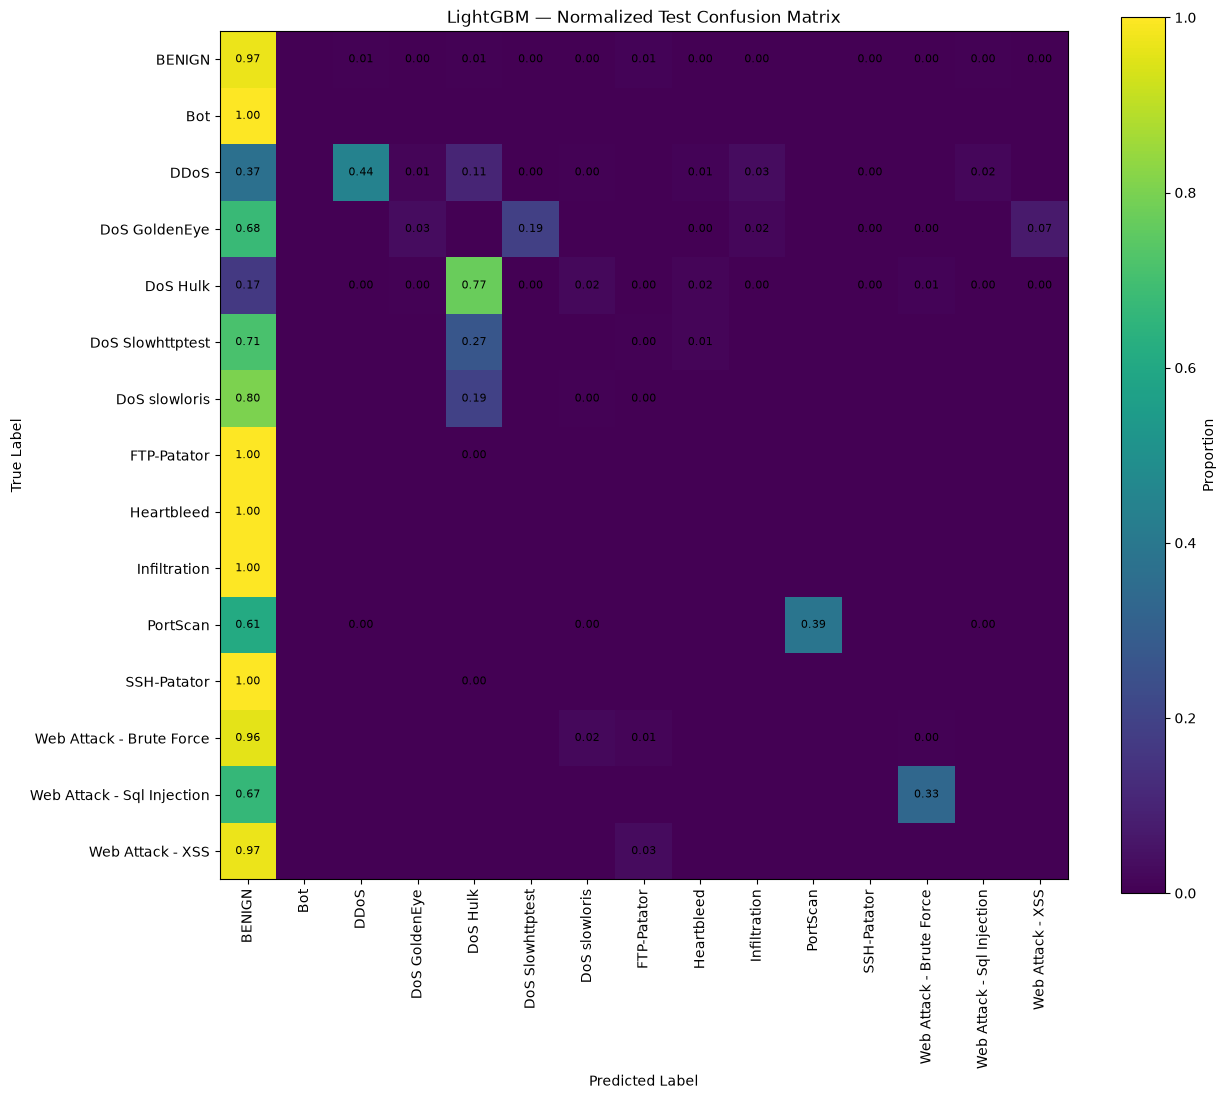

In [21]:
lgbm_cm_normalized = confusion_matrix(
    y_test,
    lgbm_predictions,
    normalize="true"
)

plt.figure(figsize=(13, 11))

plt.imshow(
    lgbm_cm_normalized,
    interpolation="nearest"
)

plt.title("LightGBM — Normalized Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar(label="Proportion")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

for i in range(lgbm_cm_normalized.shape[0]):
    for j in range(lgbm_cm_normalized.shape[1]):
        value = lgbm_cm_normalized[i, j]

        if value > 0:
            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

plt.tight_layout()
plt.show()

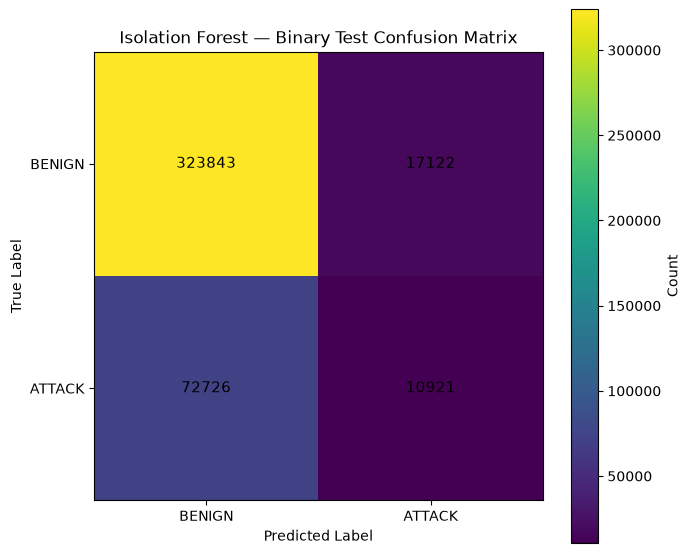

In [22]:
isolation_cm = confusion_matrix(
    y_test_binary,
    isolation_predictions
)

plt.figure(figsize=(7, 6))

plt.imshow(
    isolation_cm,
    interpolation="nearest"
)

plt.title("Isolation Forest — Binary Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar(label="Count")

plt.xticks(
    [0, 1],
    ["BENIGN", "ATTACK"]
)

plt.yticks(
    [0, 1],
    ["BENIGN", "ATTACK"]
)

for i in range(isolation_cm.shape[0]):
    for j in range(isolation_cm.shape[1]):
        value = isolation_cm[i, j]

        if value > 0:
            plt.text(
                j,
                i,
                str(value),
                ha="center",
                va="center",
                fontsize=11
            )

plt.tight_layout()
plt.show()

In [ ]:
os.makedirs("../reports/figures", exist_ok=True)

print("Reports directory ready!")

Reports directory ready!


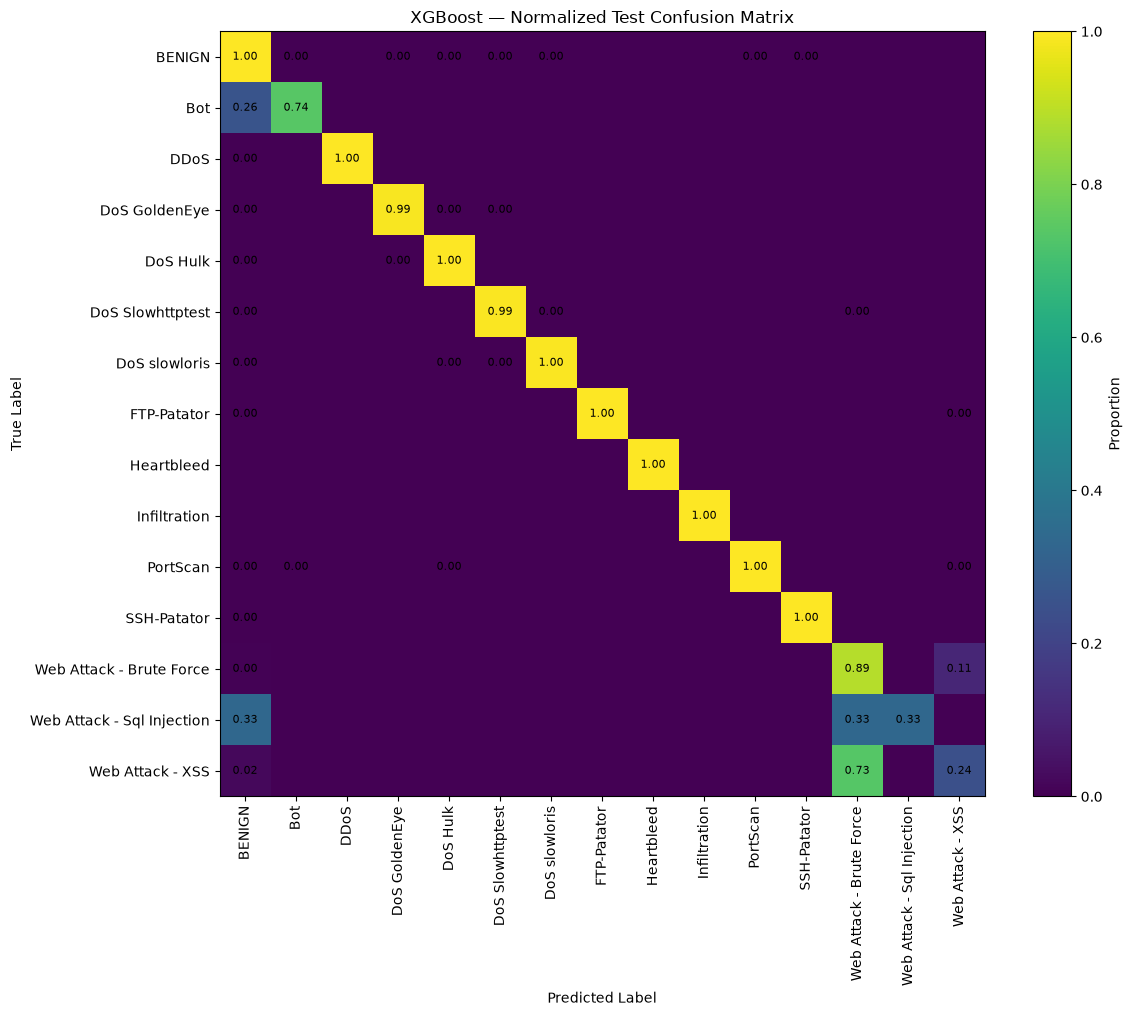

XGBoost confusion matrix saved successfully!


In [24]:
plt.figure(figsize=(12, 10))

plt.imshow(
    xgb_cm_normalized,
    interpolation="nearest"
)

plt.title("XGBoost — Normalized Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar(label="Proportion")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

for i in range(xgb_cm_normalized.shape[0]):
    for j in range(xgb_cm_normalized.shape[1]):
        value = xgb_cm_normalized[i, j]

        if value > 0:
            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

plt.tight_layout()

plt.savefig(
    "../reports/figures/xgboost_confusion_matrix_normalized.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("XGBoost confusion matrix saved successfully!")

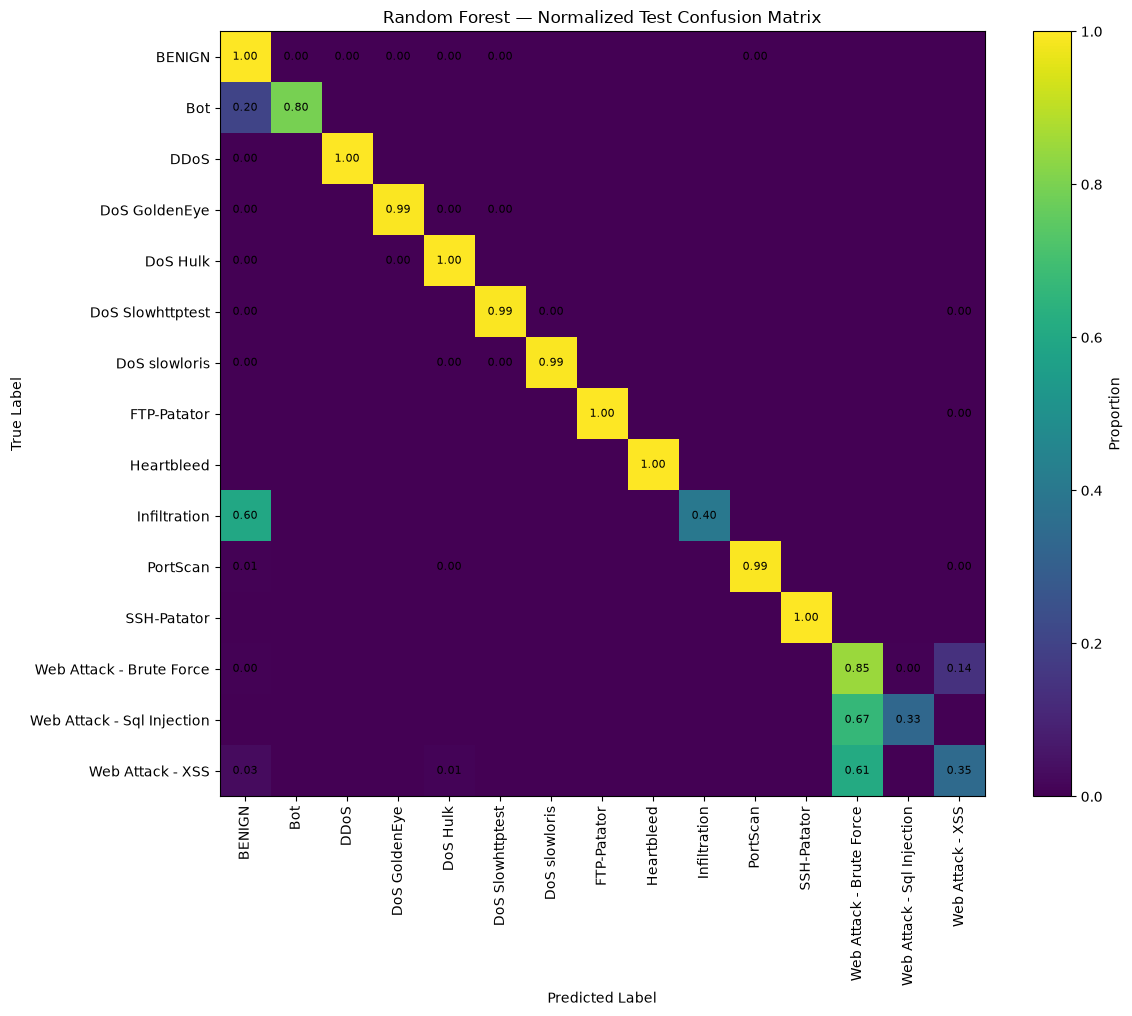

Random Forest confusion matrix saved successfully!


In [25]:
plt.figure(figsize=(12, 10))

plt.imshow(
    rf_cm_normalized,
    interpolation="nearest"
)

plt.title("Random Forest — Normalized Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar(label="Proportion")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

for i in range(rf_cm_normalized.shape[0]):
    for j in range(rf_cm_normalized.shape[1]):
        value = rf_cm_normalized[i, j]

        if value > 0:
            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

plt.tight_layout()

plt.savefig(
    "../reports/figures/random_forest_confusion_matrix_normalized.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Random Forest confusion matrix saved successfully!")

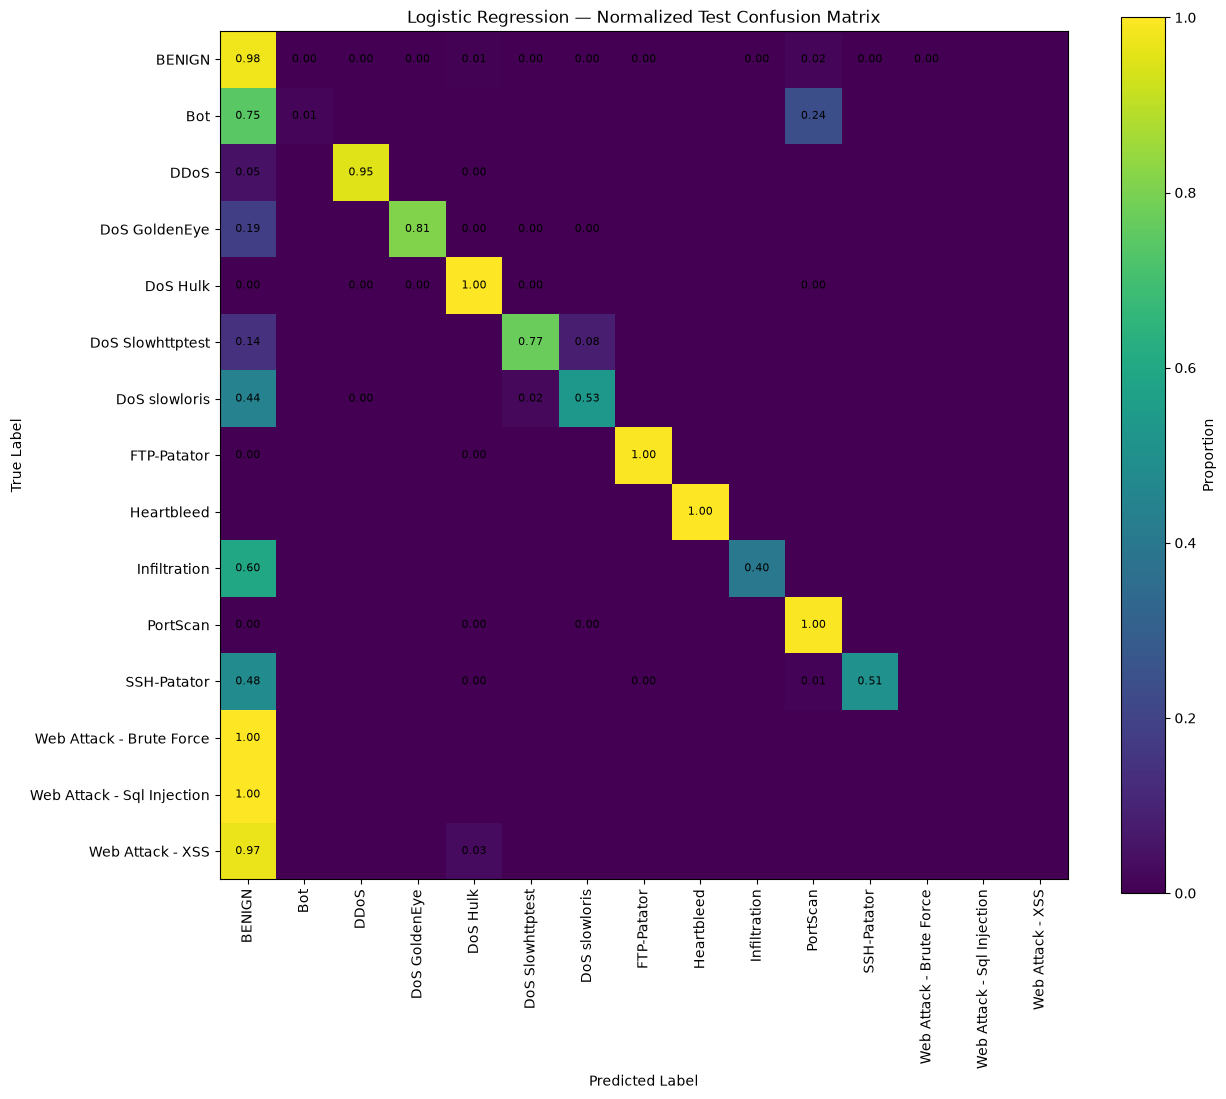

Logistic Regression confusion matrix saved successfully!


In [26]:
plt.figure(figsize=(13, 11))

plt.imshow(
    logistic_cm_normalized,
    interpolation="nearest"
)

plt.title("Logistic Regression — Normalized Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar(label="Proportion")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

for i in range(logistic_cm_normalized.shape[0]):
    for j in range(logistic_cm_normalized.shape[1]):
        value = logistic_cm_normalized[i, j]

        if value > 0:
            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

plt.tight_layout()

plt.savefig(
    "../reports/figures/logistic_regression_confusion_matrix_normalized.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Logistic Regression confusion matrix saved successfully!")

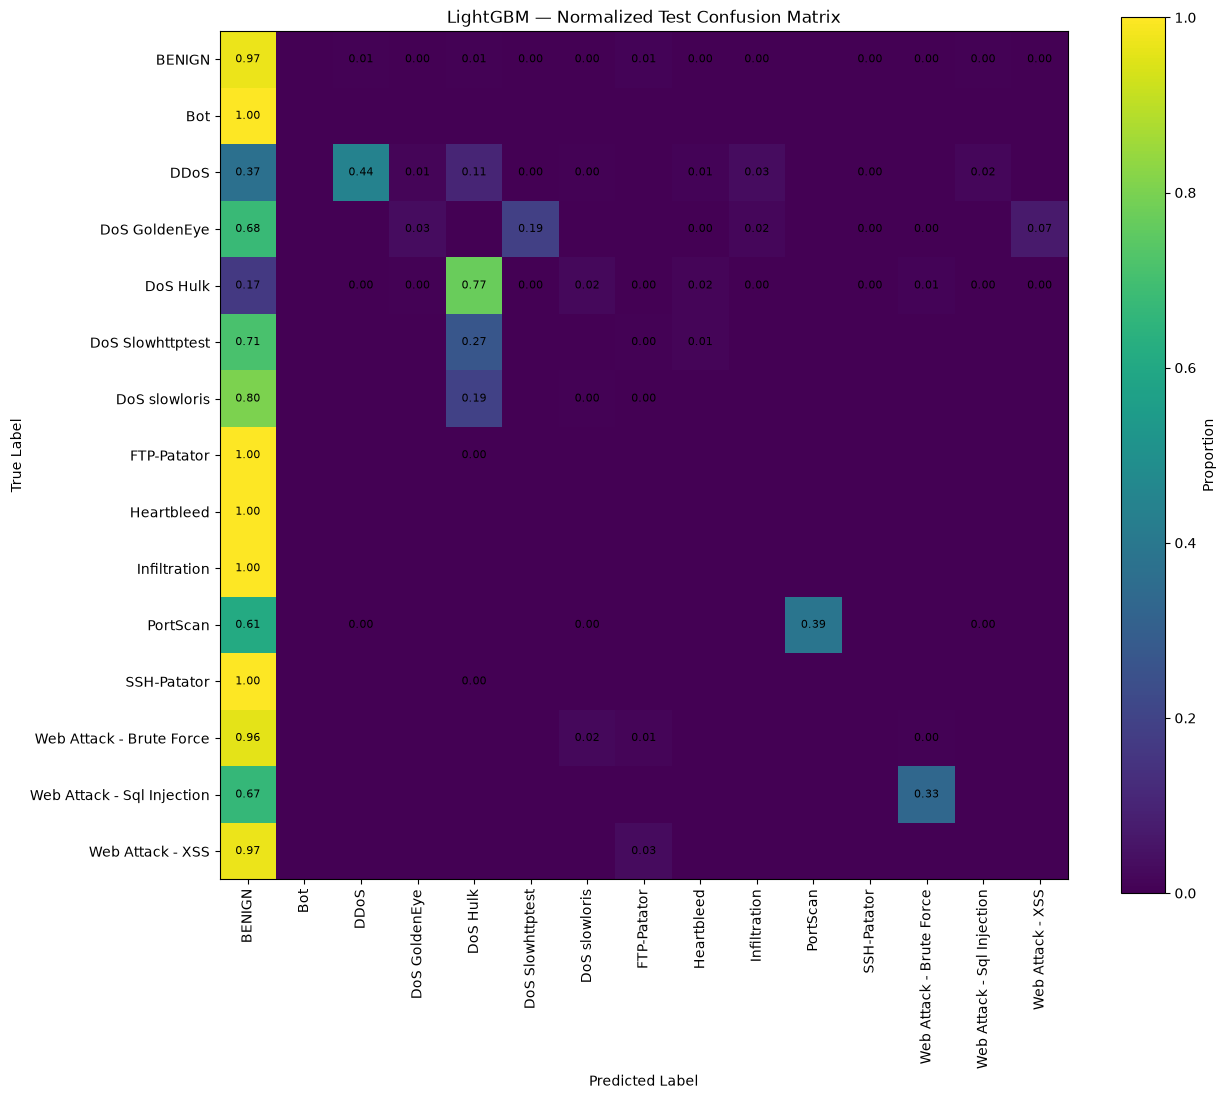

LightGBM confusion matrix saved successfully!


In [27]:
plt.figure(figsize=(13, 11))

plt.imshow(
    lgbm_cm_normalized,
    interpolation="nearest"
)

plt.title("LightGBM — Normalized Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar(label="Proportion")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

for i in range(lgbm_cm_normalized.shape[0]):
    for j in range(lgbm_cm_normalized.shape[1]):
        value = lgbm_cm_normalized[i, j]

        if value > 0:
            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

plt.tight_layout()

plt.savefig(
    "../reports/figures/lightgbm_confusion_matrix_normalized.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("LightGBM confusion matrix saved successfully!")

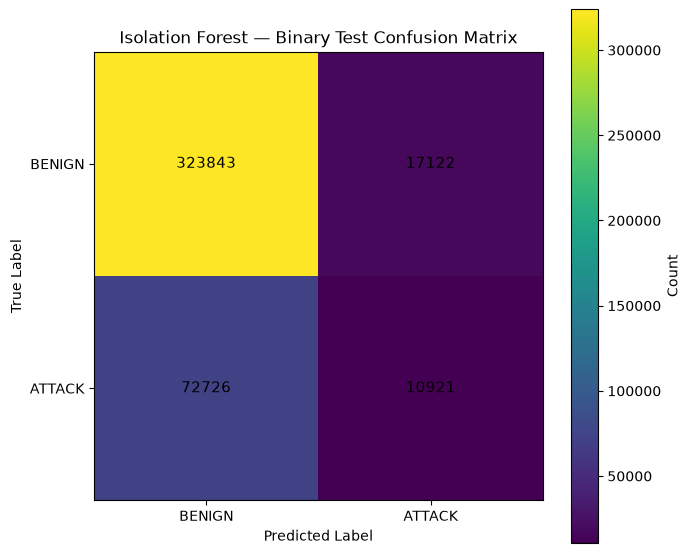

Isolation Forest confusion matrix saved successfully!


In [28]:
plt.figure(figsize=(7, 6))

plt.imshow(
    isolation_cm,
    interpolation="nearest"
)

plt.title("Isolation Forest — Binary Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar(label="Count")

plt.xticks(
    [0, 1],
    ["BENIGN", "ATTACK"]
)

plt.yticks(
    [0, 1],
    ["BENIGN", "ATTACK"]
)

for i in range(isolation_cm.shape[0]):
    for j in range(isolation_cm.shape[1]):
        value = isolation_cm[i, j]

        if value > 0:
            plt.text(
                j,
                i,
                str(value),
                ha="center",
                va="center",
                fontsize=11
            )

plt.tight_layout()

plt.savefig(
    "../reports/figures/isolation_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Isolation Forest confusion matrix saved successfully!")

In [29]:
os.makedirs("../reports/model_results", exist_ok=True)

supervised_results.to_csv(
    "../reports/model_results/supervised_model_results.csv",
    index=False
)

print("Supervised model results saved successfully!")

Supervised model results saved successfully!


In [30]:
isolation_results.to_csv(
    "../reports/model_results/isolation_forest_results.csv",
    index=False
)

print("Isolation Forest results saved successfully!")

Isolation Forest results saved successfully!


In [31]:
evaluation_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "Isolation Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        xgb_accuracy,
        lgbm_accuracy,
        isolation_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision,
        xgb_precision,
        lgbm_precision,
        isolation_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall,
        xgb_recall,
        lgbm_recall,
        isolation_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1,
        xgb_f1,
        lgbm_f1,
        isolation_f1
    ]
})

evaluation_summary

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.974245,0.716180,0.596724,0.620661
1,Random Forest,0.998606,0.905726,0.846498,0.865367
2,XGBoost,0.998931,0.941403,0.878790,0.895094
3,LightGBM,0.883322,0.246570,0.174378,0.196361
4,Isolation Forest,0.788400,0.389438,0.130561,0.195559


In [32]:
evaluation_summary.to_csv(
    "../reports/model_results/evaluation_summary.csv",
    index=False
)

print("Combined evaluation summary saved successfully!")

Combined evaluation summary saved successfully!


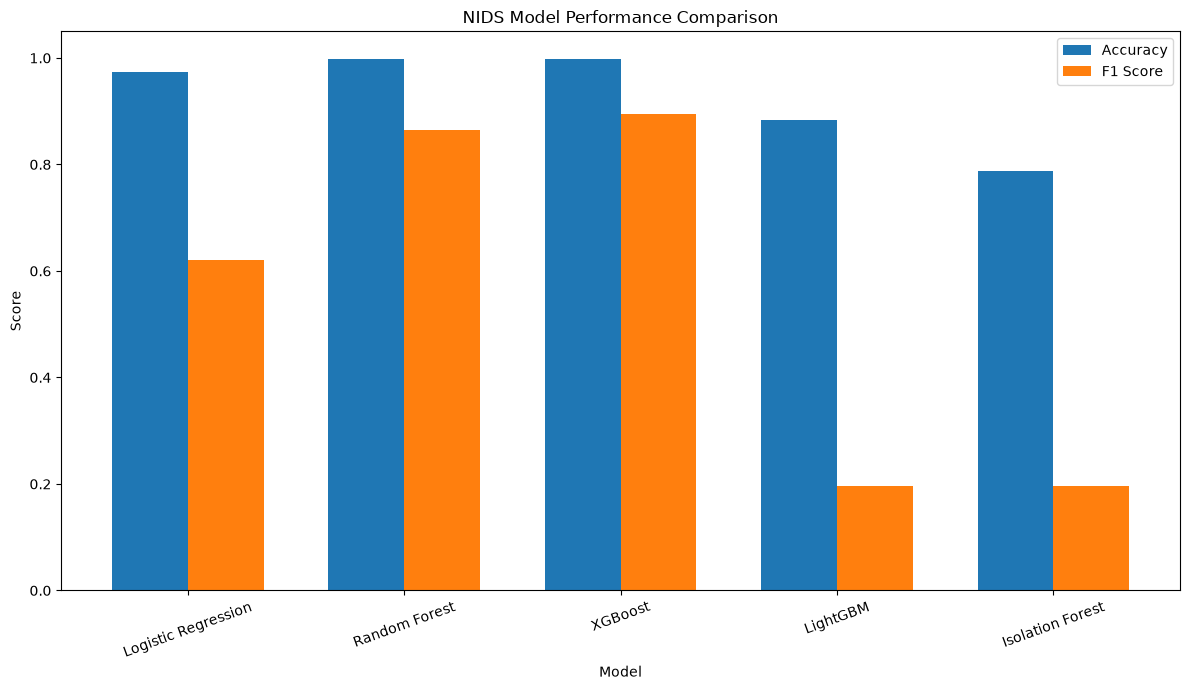

Model comparison chart saved successfully!


In [33]:
plt.figure(figsize=(12, 7))

x = np.arange(len(evaluation_summary["Model"]))
width = 0.35

plt.bar(
    x - width / 2,
    evaluation_summary["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x + width / 2,
    evaluation_summary["F1 Score"],
    width,
    label="F1 Score"
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("NIDS Model Performance Comparison")

plt.xticks(
    x,
    evaluation_summary["Model"],
    rotation=20
)

plt.ylim(0, 1.05)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/figures/model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Model comparison chart saved successfully!")

In [34]:
expected_files = [
    "../reports/figures/xgboost_confusion_matrix_normalized.png",
    "../reports/figures/random_forest_confusion_matrix_normalized.png",
    "../reports/figures/logistic_regression_confusion_matrix_normalized.png",
    "../reports/figures/lightgbm_confusion_matrix_normalized.png",
    "../reports/figures/isolation_forest_confusion_matrix.png",
    "../reports/figures/model_performance_comparison.png",
    "../reports/model_results/supervised_model_results.csv",
    "../reports/model_results/isolation_forest_results.csv",
    "../reports/model_results/evaluation_summary.csv"
]

for file_path in expected_files:
    status = "FOUND" if os.path.exists(file_path) else "MISSING"
    print(f"{status}: {file_path}")

FOUND: ../reports/figures/xgboost_confusion_matrix_normalized.png
FOUND: ../reports/figures/random_forest_confusion_matrix_normalized.png
FOUND: ../reports/figures/logistic_regression_confusion_matrix_normalized.png
FOUND: ../reports/figures/lightgbm_confusion_matrix_normalized.png
FOUND: ../reports/figures/isolation_forest_confusion_matrix.png
FOUND: ../reports/figures/model_performance_comparison.png
FOUND: ../reports/model_results/supervised_model_results.csv
FOUND: ../reports/model_results/isolation_forest_results.csv
FOUND: ../reports/model_results/evaluation_summary.csv


In [35]:
print("=" * 70)
print("PHASE 6 — MODEL EVALUATION COMPLETED")
print("=" * 70)

print("\nDataset:")
print(f"Test samples: {len(y_test):,}")
print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"Number of features: {len(FEATURES)}")

print("\nSupervised Models:")
print(supervised_results.to_string(index=False))

print("\nIsolation Forest:")
print(isolation_results.to_string(index=False))

print("\nKey Evaluation Findings:")
print("- XGBoost achieved the highest Macro F1 among the supervised models.")
print("- Random Forest also achieved strong multiclass performance.")
print("- Logistic Regression showed weaker minority-class detection.")
print("- LightGBM showed strong bias toward the BENIGN class.")
print("- Isolation Forest detected only a small proportion of attacks.")
print("- Accuracy alone is not sufficient because the dataset is highly imbalanced.")

print("\nSaved evaluation figures and result files under:")
print("../reports/figures/")
print("../reports/model_results/")

print("\nPhase 6 completed successfully!")

PHASE 6 — MODEL EVALUATION COMPLETED

Dataset:
Test samples: 424,612
Number of classes: 15
Number of features: 45

Supervised Models:
              Model  Accuracy  Macro Precision  Macro Recall  Macro F1
Logistic Regression  0.974245         0.716180      0.596724  0.620661
      Random Forest  0.998606         0.905726      0.846498  0.865367
            XGBoost  0.998931         0.941403      0.878790  0.895094
           LightGBM  0.883322         0.246570      0.174378  0.196361

Isolation Forest:
           Model  Accuracy  Precision   Recall  F1 Score
Isolation Forest    0.7884   0.389438 0.130561  0.195559

Key Evaluation Findings:
- XGBoost achieved the highest Macro F1 among the supervised models.
- Random Forest also achieved strong multiclass performance.
- Logistic Regression showed weaker minority-class detection.
- LightGBM showed strong bias toward the BENIGN class.
- Isolation Forest detected only a small proportion of attacks.
- Accuracy alone is not sufficient becaus